In [3]:
import numpy as np 
import pandas as pd
from src import utils, redcells, db
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from pathlib import Path
%matplotlib inline
%load_ext autoreload
%autoreload 2
ROOT_PATH = "Z:/data/PROC"
RET_PATH = "D:/retinotopy/aligned_xy/behav"
MDL_PATH = "D:/mouseobj/"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
db_ = []
db_.append({'mname': 'VG56', 'datexp': '2026_07_15', 'blk':'3','stim':'short3'})
db_.append({'mname': 'VG58', 'datexp': '2026_07_15', 'blk':'2','stim':'short3'})
db_.append({'mname': 'VG59', 'datexp': '2026_07_15', 'blk':'2','stim':'short3'})
db_.append({'mname': 'VG70', 'datexp': '2026_08_13', 'blk':'3','stim':'8x2task'}) #3
db_.append({'mname': 'VG69', 'datexp': '2026_08_14', 'blk':'2','stim':'8x2task'})
db_.append({'mname': 'VG66', 'datexp': '2026_08_13', 'blk':'2','stim':'8x2task'})
db_.append({'mname': 'VG64', 'datexp': '2026_08_14', 'blk':'2','stim':'8x2task'})
db_.append({'mname': 'VG63', 'datexp': '2026_08_14', 'blk':'2','stim':'8x2task'})
db_ = pd.DataFrame(db_)

In [ ]:
from scipy.stats import zscore
def get_stim_response_mtx(m, segment=(0, 100), z=False):
    avg_resp = np.mean(m.interp_spks[:,:,segment[0]:segment[1]], axis=2)
    if z:
        avg_resp = zscore(avg_resp, axis=1)
    nreps = m.frameselector.groupby(['istim']).trial_no.nunique().values.min()
    resp_stim_rep = np.full((avg_resp.shape[0], 16, nreps), np.nan)
    for i in range(1,17):
        trials = m.frameselector.query(f'istim == {i}').trial_no.unique() - 1 
        trials = trials[:nreps].astype(int)
        resp_stim_rep[:,i-1, :] = avg_resp[:,trials]
    return resp_stim_rep

def get_rsm(m, resp_stim_rep):
    ncat = 8
    total_samples = ncat * 2
    representation_matrix = np.zeros((total_samples, total_samples))
    nreps = m.frameselector.groupby(['istim']).trial_no.nunique().values.min()
    for i in range(total_samples):
        first_h = nreps//2
        instance_response = resp_stim_rep[:,i,:]
        fh_neurons = instance_response[:,:first_h].mean(axis=1)
        sh_neurons = instance_response[:,first_h:].mean(axis=1)
        representation_matrix[i,i] = np.corrcoef(fh_neurons, sh_neurons)[0,1]


    from itertools import combinations
    pairs = list(combinations(np.arange(total_samples),2))
    for pair in pairs:
        intance_a = resp_stim_rep[:,pair[0],:]
        intance_b = resp_stim_rep[:,pair[1],:]
        fh_neurons = intance_a.mean(axis=1)
        sh_neurons = intance_b.mean(axis=1)
        representation_matrix[pair[0],pair[1]] = np.corrcoef(fh_neurons, sh_neurons)[0,1]
        representation_matrix[pair[1],pair[0]] = np.corrcoef(fh_neurons, sh_neurons)[0,1]
    return representation_matrix

def filter_neurons(m, area=None, plane=0, ctype="exc"):
    ix_area = np.isin(m.iarea, area)
    if plane == 1:
        ix_plane = (m._iplane >= 10) #deep 
    elif plane == 2:
        ix_plane = (m._iplane < 10) #sup
    elif plane == 0:
        ix_plane = np.ones_like(m._iplane, dtype=bool)
    else:
        raise ValueError("Layer must be 1 or 2 for depths, or 0 for all planes")
    if ctype == "exc":
        ix_type = ~m.isred[:,0].astype(bool)
    elif ctype == "inh":
        ix_type = m.isred[:,0].astype(bool)
    else:
        raise ValueError("Cell type must be 'exc' or 'inh'")
    return ix_area, ix_plane, ix_type

def get_DI_GI_df(avg_mice_rep_mtx):
    Gcamp6_df_pair_DI = pd.DataFrame()
    areas = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
    ctype = ['exc', 'inh']
    cat = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved'] 
    for i_a, area in enumerate(areas):
        for ic, ct in enumerate(ctype):
            df = pd.DataFrame()
            behav_m = avg_mice_rep_mtx[i_a, ic, :, :] # gets the representational sim matrix for the area and layer
            only_train = behav_m[::2,::2] # gets the training instances
            a, b = np.triu_indices(8,1) # gets the upper triangle indices
            positive_cat = []
            negative_cat = []
            di_index = []
            for i in zip(a,b): #loops over all the posible pairs
                positive_cat.append(cat[i[0]])
                negative_cat.append(cat[i[1]])
                a_ab = only_train[i[0],i[0]] - only_train[i[0],i[1]] #x_11 - x_12
                b_ab = only_train[i[1],i[1]] - only_train[i[0],i[1]] #x_22 - x_12
                di_avg = np.mean([a_ab, b_ab]) # avg
                di_index.append(di_avg)
            df["positive_category"] = np.array(positive_cat)
            df["negative_category"] = np.array(negative_cat)
            df["DI_brain"] = np.array(di_index)
            df["area"] = area
            df["ctype"] = ct
            Gcamp6_df_pair_DI = pd.concat([Gcamp6_df_pair_DI, df])
    Gcamp6_df_pair_DI.reset_index(inplace=True, drop=True)
    Gcamp6_df_pair_GI = pd.DataFrame()
    for i_a, area in enumerate(areas):
        for ic, ct in enumerate(ctype):
            df = pd.DataFrame()
            behav_m = avg_mice_rep_mtx[i_a, ic, :, :] # gets the representational sim matrix for the area and layer
            cross = behav_m[::2,1::2] # gets the crosstab
            a, b = np.triu_indices(8,1) # gets the upper triangle indices
            positive_cat = []
            negative_cat = []
            gi_index = []
            for i in zip(a,b): #loops over all the posible pairs
                positive_cat.append(cat[i[0]])
                negative_cat.append(cat[i[1]])
                ap_a = cross[i[0],i[0]] 
                ap_b = cross[i[1],i[0]] 
                bp_a = cross[i[0],i[1]]
                bp_b = cross[i[1],i[1]]
                gi = ((ap_a - ap_b) + (bp_b - bp_a))/2
                gi_index.append(gi)
            df["positive_category"] = np.array(positive_cat)
            df["negative_category"] = np.array(negative_cat)
            df["GI_brain"] = np.array(gi_index)
            df["area"] = area
            df["ctype"] = ct
            Gcamp6_df_pair_GI = pd.concat([Gcamp6_df_pair_GI, df])
    Gcamp6_df_pair_GI.reset_index(inplace=True, drop=True)
    behav_new_metrics = pd.merge(Gcamp6_df_pair_DI, Gcamp6_df_pair_GI, on=['positive_category', 'negative_category', 'area', 'ctype'])
    behav_new_metrics["category_pair"] = behav_new_metrics["positive_category"].str.lower() + "/" + behav_new_metrics["negative_category"].str.lower()
    return behav_new_metrics

def DI_matrix(df_only100, ax):
    df_c = df_only100.copy()
    df_c['positive_category'] = df_only100['negative_category']
    df_c['negative_category'] = df_only100['positive_category']
    crosstab = pd.concat([df_only100, df_c])
    crosstab_GI = crosstab[['positive_category', 'negative_category', 'GI_norm_brain']]
    crosstab_GI = pd.crosstab(crosstab_GI['positive_category'], crosstab_GI['negative_category'], values = crosstab_GI['GI_norm_brain'], aggfunc='mean')
    index_order = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved']
    crosstab_ordered_GI = crosstab_GI.reindex(index = index_order, columns=index_order)
    crosstab_DI = crosstab[['positive_category', 'negative_category', 'DI_brain']]
    crosstab_DI = pd.crosstab(crosstab_DI['positive_category'], crosstab_DI['negative_category'], values = crosstab_DI['DI_brain'], aggfunc='mean')
    index_order = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved']
    crosstab_ordered_DI = crosstab_DI.reindex(index = index_order, columns=index_order)
    upper_mask = np.triu(np.ones_like(crosstab_ordered_GI, dtype=bool))
    g = sns.heatmap(crosstab_ordered_GI, cmap='RdBu_r', annot=True, fmt='.2f', cbar=False, 
                annot_kws={"size": 10}, vmax=.75, vmin=-.75, cbar_kws={'label': 'Neural discrimination index', 
                'orientation': 'horizontal', 'pad': 0.25, 'shrink':.8},  mask=~upper_mask, ax = ax)

    sns.heatmap(crosstab_ordered_DI, cmap='RdBu_r', annot=True, fmt='.2f', cbar=False, vmax=.75, vmin=-.75, mask=upper_mask, annot_kws={"size": 10}, ax=ax)
    ax.plot([-1.5, len(crosstab_ordered_GI)], [-1.5, len(crosstab_ordered_GI)], color='k', linestyle='--', linewidth=1, clip_on=False)
    #remove tick marks
    ax.tick_params(axis='both', which='both', length=0, labelsize=10, pad=5)
    #increase the space of the tick labels and the plot
    #ax.text(.5, 0.2, "Test", size=10, rotation=-40, ha='center', va='center', clip_on=False)
    #ax.text(0.25,.65, "Train", size=10, rotation=-40, ha='center', va='center', clip_on=False)
    anchor = -1.9
    ax.text(anchor + 0.4, anchor + 1.1, "Test", size=14,
            rotation=-45, ha='left', va='bottom', clip_on=False)
    
    ax.text(anchor - 0.2, anchor + 2, "Train", size=14,
            rotation=-45, ha='left', va='bottom', clip_on=False)
    ax.set_xlabel("")
    ax.set_ylabel("");
    cb = g.collections[0].colorbar
    return cb

In [6]:
small_areas = np.array([8,0,1,2,9,3,4,5,6,7])
areas_names = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISrll']
overall_mtx = np.full((db_.shape[0], len(small_areas), 2, 16, 16), np.nan)
for i, row in db_.iterrows():
    name, datexp, blk = row['mname'], row["datexp"], row["blk"]    
    m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, return_iscell=True,
                        data_path=ROOT_PATH, ret_path=RET_PATH,  mdl_path=MDL_PATH, opt_tlag = 1)
    speed = m.frameselector['speed'].to_numpy().mean()
    ntrials = m.frameselector["trial_no"].max()
    save_path = Path(MDL_PATH).joinpath(f"{m.name}/{m.datexp}/{m.blk}")
    print(f"average speed {speed:.2f}, number of trials {ntrials}")
    stim_resp = get_stim_response_mtx(m, segment=(0, 100), z=True)
    for iarea, a in enumerate(small_areas):
        for ic, ctype in enumerate(["exc", "inh"]):
            ia, ip, it = filter_neurons(m, area=a, plane=0, ctype=ctype)
            selection = ia & ip & it
            sel_neurons = stim_resp[selection,:,:]
            rsm_ = get_rsm(m, sel_neurons)
            overall_mtx[i, iarea, ic,:,:] = rsm_
    np.save(save_path.joinpath("overall_mtx_closed_loop_z.npy"), overall_mtx[i,:,:,:,:])

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG56\2026_07_15\3
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'interp_spks'])
average speed 28.46, number of trials 399.0


C:\Users\labadmin\AppData\Local\Temp\ipykernel_34364\3014813336.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  avg_resp = zscore(avg_resp, axis=1)


Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG58\2026_07_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'interp_spks'])
average speed 33.50, number of trials 399.0


c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG59\2026_07_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'interp_spks'])
average speed 26.01, number of trials 399.0


...

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG66\2026_08_13\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'interp_spks'])
average speed 43.62, number of trials 399.0


C:\Users\labadmin\AppData\Local\Temp\ipykernel_34364\3014813336.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  avg_resp = zscore(avg_resp, axis=1)


Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG64\2026_08_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'interp_spks'])
average speed 15.01, number of trials 399.0


C:\Users\labadmin\AppData\Local\Temp\ipykernel_34364\3014813336.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  avg_resp = zscore(avg_resp, axis=1)


Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG63\2026_08_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'interp_spks'])
average speed 5.92, number of trials 203.0


In [7]:
#load the overall_mtx for all mice
overall_mtx = np.full((db_.shape[0], len(small_areas), 2, 16, 16), np.nan)
for i, row in db_.iterrows():
    name, datexp, blk = row['mname'], row["datexp"], row["blk"]    
    save_path = Path(MDL_PATH).joinpath(f"{name}/{datexp}/{blk}")
    overall_mtx[i,:,:,:,:] = np.load(save_path.joinpath("overall_mtx_closed_loop_z.npy"))
mean_mtx = np.nanmean(overall_mtx, axis=0)

In [255]:
di_df = get_DI_GI_df(mean_mtx)
di_vg = di_df.assign(GI_norm_brain = di_df['GI_brain']/di_df['DI_brain'])

In [256]:
from scipy.stats import ttest_rel
def significance(pval):
    if  (pval >= .05) or (np.isnan(pval)):
        sig = ''
    elif (pval < .05) and (pval >= .01):
        sig = '*'
    elif (pval < .01) and (pval >= .001):
        sig = '**'
    else:
        sig = '***'
    return sig

def get_DI_GI_behav(first100df):
    df_c = first100df.copy()
    df_c['positive_category'] = first100df['negative_category']
    df_c['negative_category'] = first100df['positive_category']
    crosstab = pd.concat([first100df, df_c])
    crosstab_GI = crosstab[['positive_category', 'negative_category', 'GI_behav']]
    crosstab_GI = pd.crosstab(crosstab_GI['positive_category'], crosstab_GI['negative_category'], values = crosstab_GI['GI_behav'], aggfunc='mean')
    index_order = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved']
    crosstab_ordered_GI = crosstab_GI.reindex(index = index_order, columns=index_order)
    crosstab_DI = crosstab[['positive_category', 'negative_category', 'DI_behav']]
    crosstab_DI = pd.crosstab(crosstab_DI['positive_category'], crosstab_DI['negative_category'], values = crosstab_DI['DI_behav'], aggfunc='mean')
    index_order = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved']
    crosstab_ordered_DI = crosstab_DI.reindex(index = index_order, columns=index_order)
    a,b = np.triu_indices(8, k=1)
    bhv_gi_num_ordered  = []
    bhv_di_ordered = []
    for i in zip(a,b):
        bhv_gi_num_ordered.append(crosstab_ordered_GI.iloc[i[0],i[1]])
        bhv_di_ordered.append(crosstab_ordered_DI.iloc[i[0],i[1]])
    bhv_gi_num_ordered = np.array(bhv_gi_num_ordered)
    bhv_di_ordered = np.array(bhv_di_ordered)
    inv_new_metrics = pd.read_csv(r"C:\Users\labadmin\Documents\oneshot-neural\results\gcamp6_behav_new_metrics.csv", index_col=0)
    cat_pairs = inv_new_metrics.query("area == 'V1' & layer == 1")["category_pair"].values
    DI_metrics_behav = pd.DataFrame({'Category_pair': cat_pairs, 'GI_behav': bhv_gi_num_ordered, 'DI_behav': bhv_di_ordered})
    return DI_metrics_behav

from scipy import stats
def perm_test(behav_df, brain_df, area, ctype, metric='GI_norm', n_shuffles=10000, plot=None):
    metric_brain = f"{metric}_brain"
    metric_behav = f"{metric}_behav"
    # add indexes to behav_df for permutation BEHAVIOR
    positive_cat = behav_df["Category_pair"].str.split("/").str[0]
    negative_cat = behav_df["Category_pair"].str.split("/").str[1]
    behav_df = behav_df.assign(positive_cat=positive_cat, negative_cat=negative_cat)
    cat_map = {'leaves': 0, 'circles': 1, 'dryland': 2, 'rocks': 3, 'tiles': 4, 'squares': 5, 'rleaves': 6, 'paved': 7} # this df has them lowecase
    behav_df = behav_df.assign(positive_cat_num=behav_df['positive_cat'].map(cat_map), negative_cat_num=behav_df['negative_cat'].map(cat_map))
    # BRAIN
    #subsample the area / layer 
    queried = brain_df.query(f"area=='{area}' & ctype=='{ctype}'").copy()
    queried = queried.assign(positive_category=queried["positive_category"].str.lower(), negative_category=queried["negative_category"].str.lower())
    # map the 'category' column to the new names using the cat_map
    queried.loc[:, "pos_idx"] = queried["positive_category"].map(cat_map)
    queried.loc[:, "neg_idx"] = queried["negative_category"].map(cat_map)
    brain_vals = queried[metric_brain].values
    pos_map = queried["pos_idx"].astype(int).values
    neg_map = queried["neg_idx"].astype(int).values

    #lets create the matrix that maps the brain values to the behav values
    n_cats = 8
    behav_mat = np.zeros((n_cats, n_cats))
    for i, row in behav_df.iterrows():
        p, n = int(row['positive_cat_num']), int(row['negative_cat_num'])
        val = row[metric_behav]
        behav_mat[p, n] = val
        behav_mat[n, p] = val
    #here I get the real correlation
    real_behav_vec = behav_df[metric_behav].values
    observed_r, _  = stats.pearsonr(brain_vals, real_behav_vec)
    #print(f"Observed correlation: {observed_r:.4f}")
    #shuffle the behav matrix and get the null distribution of correlations
    null_rs = []
    n_shuffles = 10000
    rng = np.random.default_rng(42)
    for _ in range(n_shuffles):
        perm = rng.permutation(n_cats)
        shuffled_mat = behav_mat[perm, :][:, perm] #here im doing the swap
        shuffled_behav_vec = shuffled_mat[pos_map, neg_map]
        r_null, _ = stats.pearsonr(brain_vals, shuffled_behav_vec)
        null_rs.append(r_null)
    null_rs = np.array(null_rs)
    p_perm = np.sum(null_rs >= observed_r) / n_shuffles
    #print(f"permutation p-value: {p_perm:.4f}")

    if plot is not None:
        sns.histplot(null_rs, kde=True, ax=plot)
        plot.axvline(observed_r, color='red', linestyle='--', label=f'Observed r={observed_r:.4f}')
        plot.text(observed_r+0.1, plot.get_ylim()[1]*0.9, f'p={p_perm:.4f}', color='red', ha='center')
        plot.set_title(f"{area} ctype {ctype}")
        sig = significance(p_perm)
        plot.text(0.05, 0.95, f"obs r={observed_r:.4f}{sig}", transform=plot.transAxes, fontsize=8, fontweight='bold', va='top')
    return observed_r, p_perm


def regplot_perm(DI_metrics, DI_metrics_behav, metric, area, ctype, ax, norm=False, sig_coor=(.6,.4), n_shuffles=10000):
    query = f"ctype == '{ctype}' & area == '{area}'"
    if (norm == True) & (metric=='GI'):
        brain_pair_inv = DI_metrics.query(query)[f"{metric}_norm_brain"].values
        behav_inv =  DI_metrics_behav[f"{metric}_norm_behav"].values
        corr, pval = perm_test(DI_metrics_behav, DI_metrics, area=area, ctype=ctype, metric='GI_norm', n_shuffles=10000)    
    else:
        brain_pair_inv = DI_metrics.query(query)[f"{metric}_brain"].values
        behav_inv =  DI_metrics_behav[f"{metric}_behav"].values
        corr, pval = perm_test(DI_metrics_behav, DI_metrics, area=area, ctype=ctype, metric='DI', n_shuffles=10000)    
    brain_pair_inv = brain_pair_inv[~np.isnan(behav_inv)]
    behav_inv = behav_inv[~np.isnan(behav_inv)]
    sig = significance(pval)
    #if pval > .05:
    #    sns.regplot(x=behav_inv, y=brain_pair_inv, ci=95, line_kws=dict(color="r"), scatter_kws=dict(color = '#020508', s=10), fit_reg=False, ax=ax)
    #else:
    sns.regplot(x=behav_inv, y=brain_pair_inv, ci=95, line_kws=dict(color="r"), scatter_kws=dict(color = '#020508', s=10), fit_reg=True, ax=ax)
    ax.text(sig_coor[0],sig_coor[1],f" r = {corr:.2f}{sig}", color='r', fontsize=10, transform=ax.transAxes)
    ax.set_xticks([0,.5,1])
    return corr, pval, sig

from statsmodels.stats.multitest import multipletests
def get_pvals_corrected_perm(DI_metrics_behav, DI_metrics, areas, dset="test", method='fdr_bh'):
    corrs = np.full((len(areas), 2), np.nan)
    pvals = np.full((len(areas), 2), np.nan)
    for i, area in enumerate(areas):
        for ic, ctype in enumerate(['exc', 'inh']):
            if dset=='test':
                corr, pval = perm_test(DI_metrics_behav, DI_metrics, area=area, ctype=ctype, metric='GI_norm', n_shuffles=10000)
            else:
                corr, pval = perm_test(DI_metrics_behav, DI_metrics, area=area, ctype=ctype, metric='DI', n_shuffles=10000)
            corrs[i, ic] = corr
            pvals[i, ic] = pval           
    rejected, pvals_corrected_exc, _, _ = multipletests(pvals[:,0].flatten(), alpha=0.05, method=method)
    rejected, pvals_corrected_inh, _, _ = multipletests(pvals[:,1].flatten(), alpha=0.05, method=method)
    pvals_corrected = np.vstack((pvals_corrected_exc, pvals_corrected_inh)).T
    return corrs, pvals, pvals_corrected.reshape(-1, 2)

In [257]:
first100df = pd.read_csv(r"C:\Users\labadmin\Documents\GeneralizationPaper\Figure1\all_sessions_150_250_first100.csv", index_col=0)
first100df.rename(columns={"DI":"DI_behav","GI_num":"GI_behav"}, inplace=True)
first100df = first100df.assign(GI_norm_behav = first100df['GI_behav']/first100df['DI_behav'])
DI_metrics_behav = get_DI_GI_behav(first100df)
DI_metrics_behav = DI_metrics_behav.assign(GI_norm_behav = DI_metrics_behav['GI_behav']/DI_metrics_behav['DI_behav'])

In [258]:
def get_significance_stars(p):
    """Returns significance stars based on p-value."""
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return ''

from matplotlib.collections import PolyCollection
from matplotlib import colors

def plot_brain_regions(
    contours_dict, 
    values,
    ax,
    p_values=None, 
    cmap='Purples', 
    vlim=(0, 0.5), 
    show_labels=True
):
    """
    Plots a choropleth map of brain regions using provided contours and values.
    
    Parameters:
    -----------
    contours_dict : dict
        Mapping of {area_name: coordinate_array} where array is Nx2.
    values : array-like
        Values used to color each region. Must match order of contours_dict keys.
    p_values : array-like, optional
        P-values for significance stars.
    vlim : tuple
        (vmin, vmax) for the color scale.
    """
    area_names = list(contours_dict.keys())
    poly_coll = [contours_dict[name] for name in area_names]
    # 1. Create the PolyCollection
    #norm = colors.TwoSlopeNorm(vmin=vlim[0], vcenter=0, vmax=vlim[1])
    norm = colors.Normalize(vmin=vlim[0], vmax=vlim[1])
    coll = PolyCollection(
        poly_coll, 
        array=np.array(values), 
        cmap=cmap, 
        edgecolor='k', 
        norm=norm, 
        linewidth=1.5
    )
    ax.add_collection(coll)
    ax.autoscale_view()
    ax.axis("off")
    if show_labels:
        for i, name in enumerate(area_names):
            centroid = contours_dict[name].mean(axis=0)
            sig_star = ""
            if p_values is not None:
                sig_star = get_significance_stars(p_values[i])
            
            label_text = f'{sig_star}'
            if name == 'RSC':
                correction = (0, -300)
            elif name == 'MMP':
                correction = (0, -200)
            elif name == 'AM':
                correction = (0, -100)
            elif name == 'PM':
                correction = (200, 300)
            elif name == 'AL':
                correction = (100, -150)
            else:
                correction = (0, 0)
            ax.text(
                centroid[0]+correction[0], centroid[1]+correction[1], label_text, 
                ha='center', va='center', 
                fontsize=12, weight="semibold"
            )

import os
code_path = r'C:\Users\labadmin\Documents\stim\retinotopy'
out  = np.load(os.path.join(code_path, 'areas.npz'), allow_pickle = True)['out']
small_areas = np.array([8,0,1,2,9,3,4,5,6,7])
areas_names = ['VISp', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA']
countours = {areas_names[i]: out[small_areas[i]][:,[1,0]] for i in range(len(small_areas))}
poly_coll = [countours[area] for area in areas_names]

In [259]:
areas = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
corr_train, pval_train, pvals_corrected_train = get_pvals_corrected_perm(DI_metrics_behav, DI_metrics=di_vg, areas=areas, dset="train", method='fdr_bh')
corr_test, pval_test, pvals_corrected_test = get_pvals_corrected_perm(DI_metrics_behav, DI_metrics=di_vg, areas=areas, dset="test", method='fdr_bh')

In [260]:
pvals_corrected_test

array([[0.08      , 0.15575   ],
       [0.01933333, 0.039     ],
       [0.01933333, 0.2435    ],
       [0.01933333, 0.26911111],
       [0.08725   , 0.2435    ],
       [0.05033333, 0.15575   ],
       [0.5411    , 0.2435    ],
       [0.01975   , 0.15575   ],
       [0.05033333, 0.206     ],
       [0.317     , 0.2829    ]])

In [372]:
default_font = 10
fs_title = 12
from matplotlib import rcParams
rcParams["font.family"] = "Arial"
rcParams["savefig.dpi"] = 300
rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False
rcParams["axes.titlelocation"] = "left"
rcParams["axes.titleweight"] = "normal"
rcParams["font.size"] = default_font

def add_panel_label(ax, label, xoffset=-0.12, yoffset=1.08, fontsize=16, fontweight="bold", ha="center", va="bottom"):
    """
    Draw a panel letter (e.g. 'A') just outside the upper-left corner of `ax`.

    Uses `ax.transAxes` (axes-fraction coordinates, [0, 1] spans the plot box on each axis) rather
    than data coordinates - the label's position is then independent of whatever's actually
    plotted (imshow, a line plot, a PolyCollection, ...), so this works unmodified for every panel
    type in this module. `xoffset`/`yoffset` default to just outside the top-left corner
    (negative x, >1 y) and are free parameters so any panel can nudge its label if the default
    placement collides with axis tick labels/titles.
    """
    ax.text(
        xoffset, yoffset, label, transform=ax.transAxes,
        fontsize=fontsize, fontweight=fontweight, ha=ha, va=va,
    )
    return ax

def plot_interp_speed(stack_speed, ax, xlabel="Position (cm)", ylabel="Speed (cm/s)"):
    from scipy.stats import sem
    mean_speed = np.nanmean(stack_speed, axis=0)
    se_speed = sem(stack_speed, axis=0)
    ax.plot(mean_speed, color='tab:blue', linewidth=2, alpha=0.7)
    ax.fill_between(np.arange(len(mean_speed)), mean_speed - se_speed, mean_speed + se_speed, color='tab:blue', alpha=0.3)
    ax.fill_betweenx((0, 25), 0, 100, color='grey', alpha=0.3, zorder=0)
    ax.text(50, 25.5, "DI index\n quantification", ha='center', va='bottom', fontsize=8)
    ax.axvline(150, color='k', linestyle='--', linewidth=1)
    ax.axvline(300, color='k', linestyle='--', linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.annotate('maximum\ncontrast', xy=(150, 25), xytext=(150, 25), textcoords='data', ha='left', va='bottom', fontsize=8)
    ax.annotate('intertrial\nstart', xy=(300, 25), xytext=(300, 25), textcoords='data', ha='left', va='bottom', fontsize=8)

def plot_speed_interp_avg(speeds, ax, color='tab:blue', alpha=0.5):
    #set a seed for numpy random generator
    np.random.seed(42)
    dist_mean = np.zeros(10000)
    for i in range(10000):
        sample = np.random.choice(speeds, len(speeds), replace=True)
        sample_mean = np.mean(sample)
        dist_mean[i] = sample_mean
    sns.kdeplot(dist_mean, color=color, fill=True, ax=ax, alpha=alpha)
    ax.axvline(np.mean(speeds), color=color, linestyle='--')
    ax.text(np.mean(speeds) + 0.1, 0.24, '%.2f $cm/s$' % np.mean(speeds), color=color, fontsize=10)
    

In [262]:
for index, row in db_.iterrows():
    name, datexp, blk = row['mname'], row["datexp"], row["blk"]
    speed_interp = np.load(Path(MDL_PATH).joinpath(f"{name}/{datexp}/{blk}/speed_interp.npy"))
    mask = (np.mean(speed_interp, axis=1) > 0) # checks the mean across positions > 0
    speed_interp = speed_interp[mask]
    speed_mean= np.nanmean(speed_interp, axis=0, keepdims=True) #average across trials
    if index == 0:
        stack_speed = speed_mean
    else:
        stack_speed = np.concatenate((stack_speed, speed_mean), axis=0)
print(f"stack_speed shape: {stack_speed.shape}")

stack_speed shape: (8, 400)


In [263]:
g8_speed_avg = np.array([ 1.71233279,  5.09770686, 16.42165256,  0.44682569,  0.04269709,
        2.93217045])
avg_speeds_f100 = stack_speed[:,:100].mean(axis=1)

Text(0.53, 0.18, 'L2/3 Inhibitory cells')

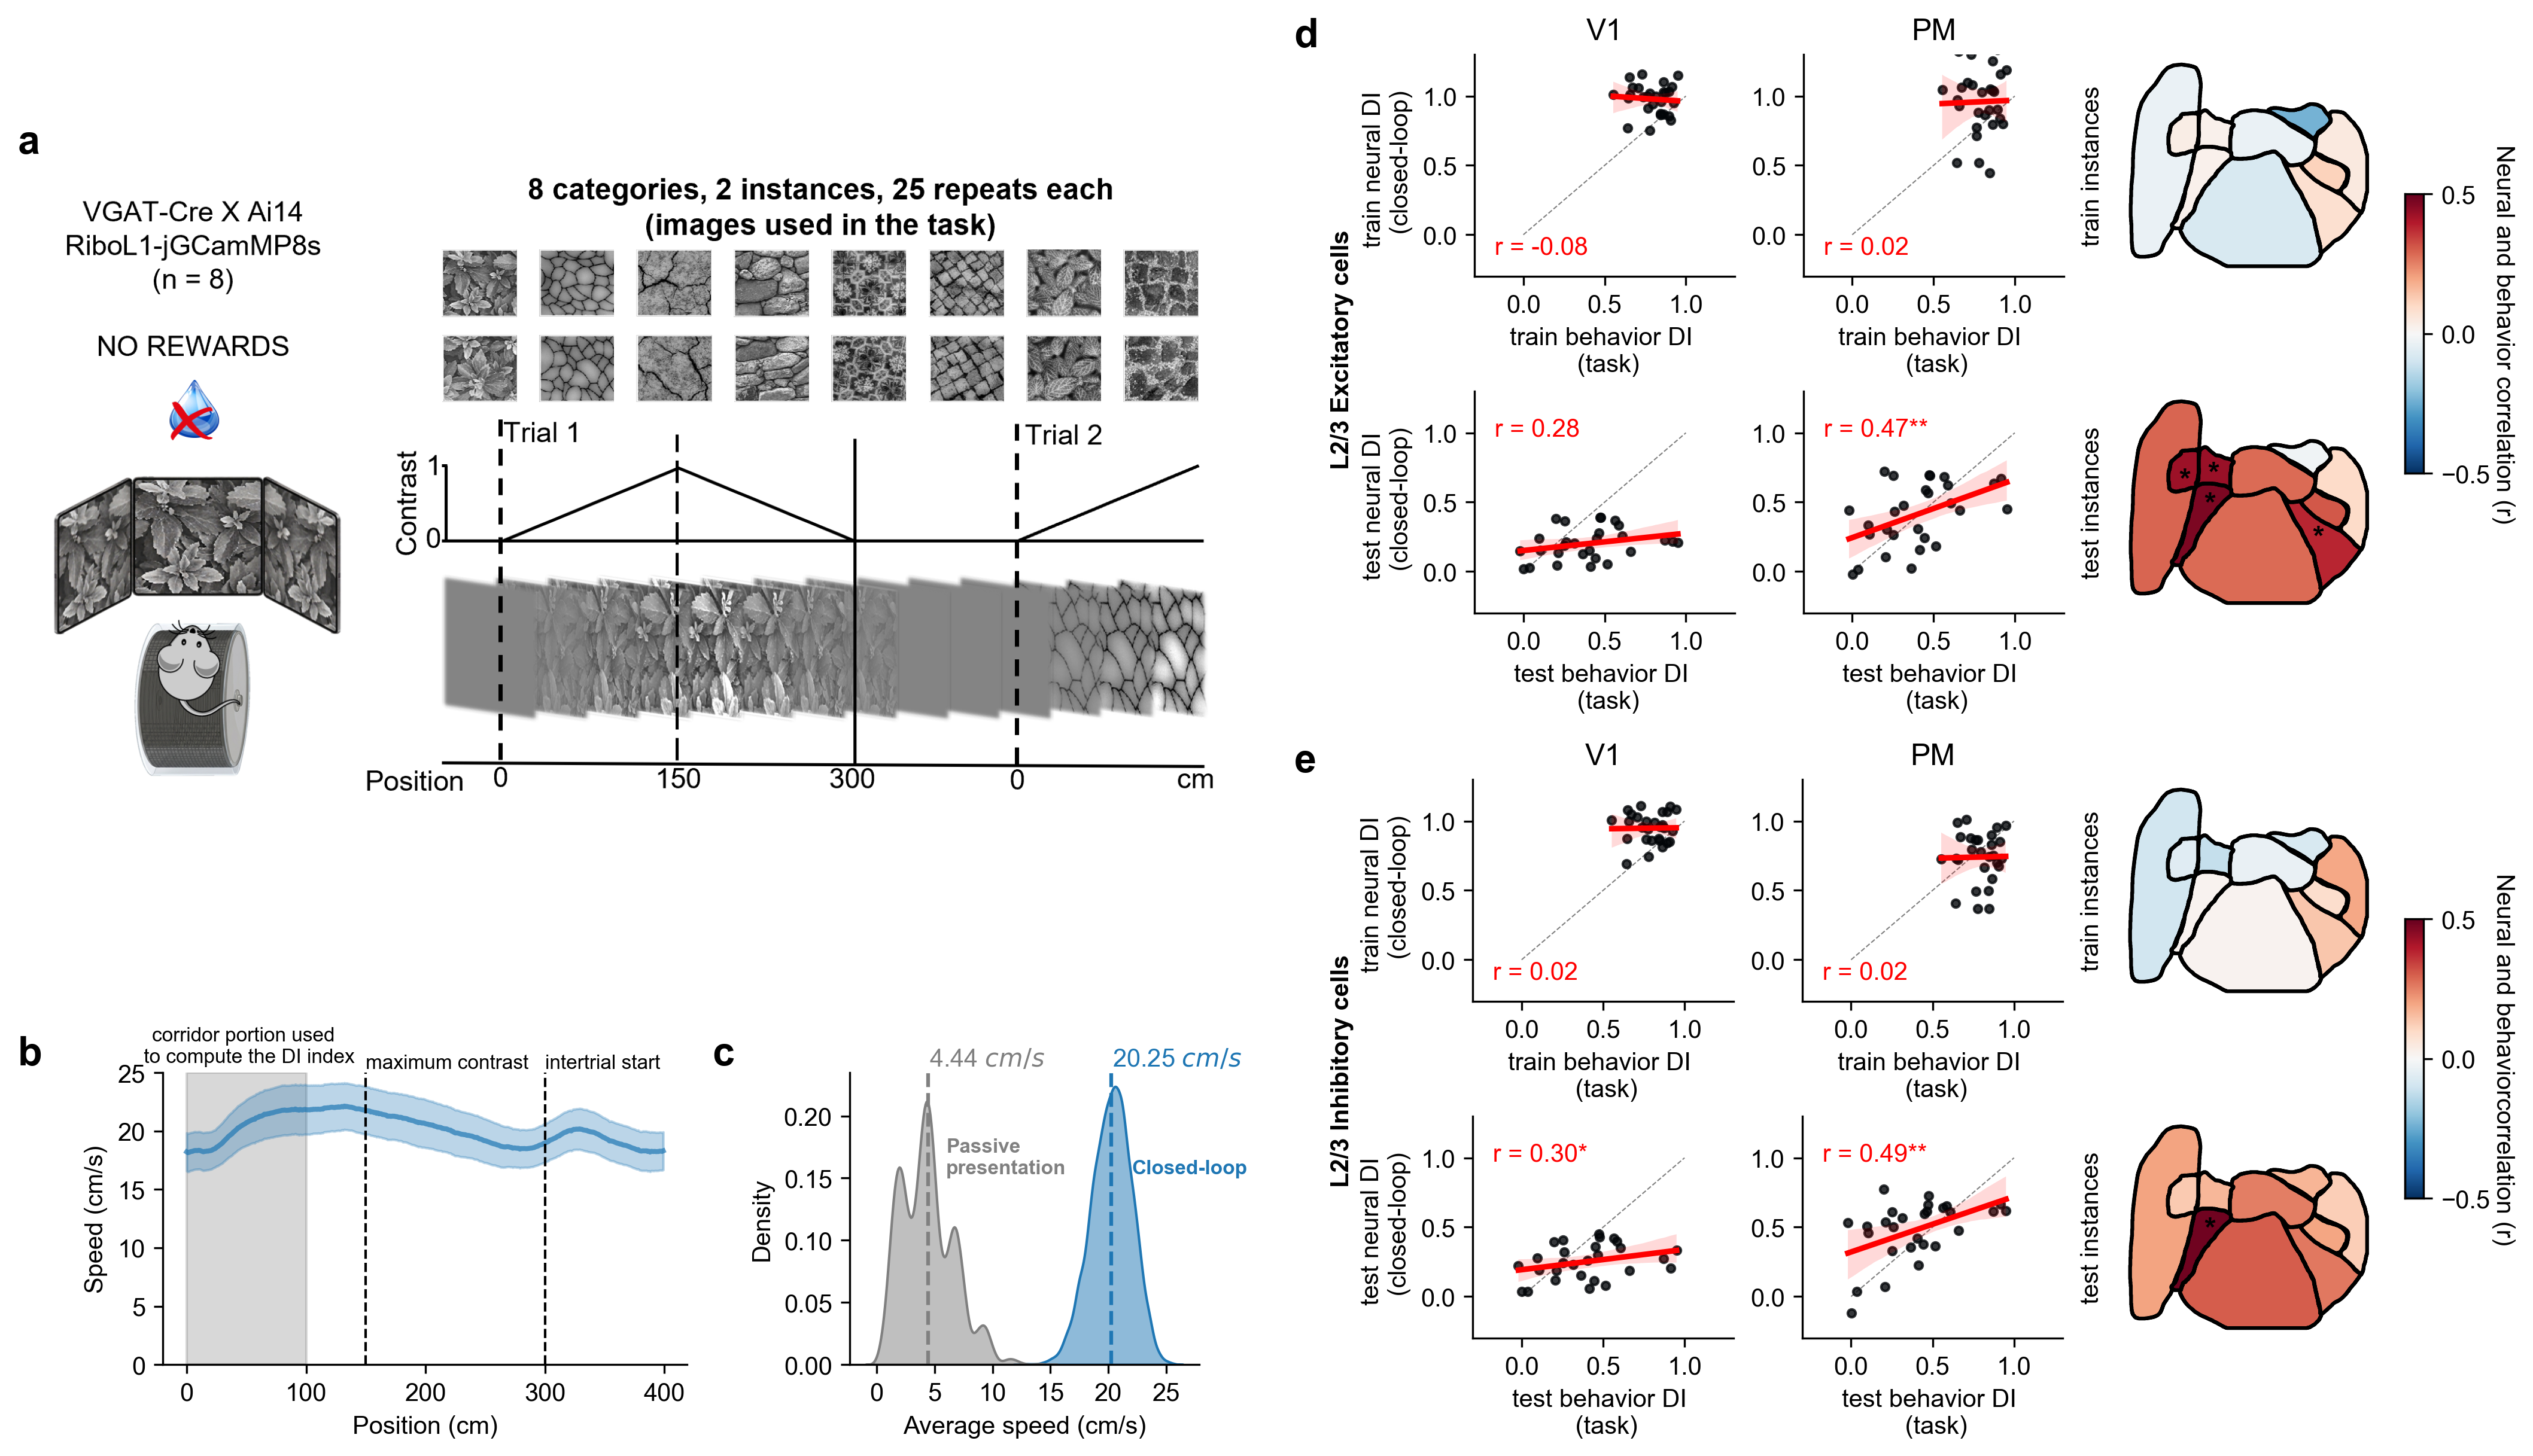

In [264]:
def show_image(ax, img_path):
    ax.imshow(plt.imread(img_path))
    ax.axis('off')
    
fig = plt.figure(figsize=(14, 8), dpi=300, layout='constrained')
subfigs = fig.subfigures(1, 2, width_ratios=[.5, .5])
img_fig = subfigs[0].subfigures(2, 1, height_ratios=[.7, .3])
img_ax = img_fig[0].subplots(1, 1)
speed_ax = img_fig[1].subplots(1, 2, width_ratios=[.6, .4])

show_image(img_ax, r"C:\Users\labadmin\Pictures\closed_loop_presentation.png")

plot_interp_speed(stack_speed, speed_ax[0], xlabel="Position (cm)", ylabel="Speed (cm/s)")
speed_ax[0].set_ylim(0, 25)
plot_speed_interp_avg(avg_speeds_f100, ax=speed_ax[1], color='tab:blue')
plot_speed_interp_avg(g8_speed_avg, ax=speed_ax[1], color='grey')


subrows = subfigs[1].subfigures(2, 1, height_ratios=[.5, .5])
exc_rel_axs = subrows[0].subplots(2, 3, width_ratios=[.33, .33, .33])
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISp", "exc", sig_coor=(.05,.1), norm=True, ax=exc_rel_axs[0,0])
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISpm", "exc", sig_coor=(.05,.1), norm=True, ax=exc_rel_axs[0,1])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISp", "exc", sig_coor=(.05,.8), norm=True, ax=exc_rel_axs[1,0])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISpm", "exc", sig_coor=(.05,.8), norm=True, ax=exc_rel_axs[1,1])
for ax in exc_rel_axs.flatten()[[0,1,3,4]]:
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlim(-0.3, 1.3)
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=.5, zorder=0)
exc_rel_axs[0,0].set_xlabel("train behavior DI \n (task)")
exc_rel_axs[0,1].set_xlabel("train behavior DI \n (task)")
exc_rel_axs[1,0].set_xlabel("test behavior DI \n (task)")
exc_rel_axs[1,1].set_xlabel("test behavior DI \n (task)")
exc_rel_axs[0,0].set_ylabel("train neural DI \n (closed-loop)")
exc_rel_axs[1,0].set_ylabel("test neural DI \n (closed-loop)")
exc_rel_axs[0,0].set_title("V1", loc="center")
exc_rel_axs[0,1].set_title("PM", loc="center")
cmap = plt.get_cmap('RdBu_r')
vmin = np.round(corr_train.min(), 1)
vmax = np.round(corr_test.max(), 1)
plot_brain_regions(countours, corr_train[:,0], ax=exc_rel_axs[0,2], p_values=pvals_corrected_train[:,0], cmap=cmap, vlim=(-vmax, vmax), show_labels=True)
plot_brain_regions(countours, corr_test[:,0], ax=exc_rel_axs[1,2], p_values=pvals_corrected_test[:,0], cmap=cmap, vlim=(-vmax, vmax), show_labels=True)
exc_rel_axs[0,2].text(-0.1, 0.5,"train instances", fontsize=10, rotation=90, ha='center', va='center', transform=exc_rel_axs[0,2].transAxes)
exc_rel_axs[1,2].text(-0.1, 0.5,"test instances", fontsize=10, rotation=90, ha='center', va='center', transform=exc_rel_axs[1,2].transAxes)
im = exc_rel_axs[0,2].collections[0]  
cbar = subrows[0].colorbar(
    im,
    ax=[exc_rel_axs[0,2], exc_rel_axs[1,2]],  
    shrink=0.5,
    aspect=15,
    pad= 0.1,
    location='right', 
)
cbar.set_label("Neural and behavior correlation (r)", rotation=270, labelpad=10)
cbar.set_ticks([-0.5, 0, 0.5])
cbar.ax.tick_params(labelsize=10)
inh_rel_axs = subrows[1].subplots(2, 3, width_ratios=[.33,.33,.33])
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISp", "inh", sig_coor=(.05,.1), norm=True, ax=inh_rel_axs[0,0])
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISpm", "inh", sig_coor=(.05,.1), norm=True, ax=inh_rel_axs[0,1])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISp", "inh", sig_coor=(.05,.8), norm=True, ax=inh_rel_axs[1,0])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISpm", "inh", sig_coor=(.05,.8), norm=True, ax=inh_rel_axs[1,1])
for ax in inh_rel_axs.flatten()[[0,1,3,4]]:
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlim(-0.3, 1.3)
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=.5, zorder=0)
inh_rel_axs[0,0].set_xlabel("train behavior DI \n (task)")
inh_rel_axs[0,1].set_xlabel("train behavior DI \n (task)")
inh_rel_axs[1,0].set_xlabel("test behavior DI \n (task)")
inh_rel_axs[1,1].set_xlabel("test behavior DI \n (task)")
inh_rel_axs[0,0].set_ylabel("train neural DI \n (closed-loop)")
inh_rel_axs[1,0].set_ylabel("test neural DI \n (closed-loop)")
inh_rel_axs[0,0].set_title("V1", loc="center")
inh_rel_axs[0,1].set_title("PM", loc="center")
plot_brain_regions(countours, corr_train[:,1], ax=inh_rel_axs[0,2], p_values=pvals_corrected_train[:,1], cmap=cmap, vlim=(-vmax, vmax), show_labels=True)
plot_brain_regions(countours, corr_test[:,1], ax=inh_rel_axs[1,2], p_values=pvals_corrected_test[:,1], cmap=cmap, vlim=(-vmax, vmax), show_labels=True)
inh_rel_axs[0,2].text(-0.1, 0.5,"train instances", fontsize=10, rotation=90, ha='center', va='center', transform=inh_rel_axs[0,2].transAxes)
inh_rel_axs[1,2].text(-0.1, 0.5,"test instances", fontsize=10, rotation=90, ha='center', va='center', transform=inh_rel_axs[1,2].transAxes)
im = inh_rel_axs[0,2].collections[0]  
cbar = subrows[1].colorbar(
    im,
    ax=[inh_rel_axs[0,2], inh_rel_axs[1,2]],  
    shrink=0.5,
    aspect=15,
    pad= 0.1,
    location='right', 
)
cbar.set_label("Neural and behaviorcorrelation (r)", rotation=270, labelpad=10)
cbar.set_ticks([-0.5, 0, 0.5])
cbar.ax.tick_params(labelsize=10)
sns.despine()
add_panel_label(img_ax, "a", xoffset=0, yoffset=1, fontsize=16, fontweight="bold", ha="right", va="bottom")
add_panel_label(speed_ax[0], "b", xoffset=-0.23, yoffset=1, fontsize=16, fontweight="bold", ha="right", va="bottom")
add_panel_label(speed_ax[1], "c", xoffset=-0.33, yoffset=1, fontsize=16, fontweight="bold", ha="right", va="bottom")
add_panel_label(exc_rel_axs[0,0], "d", xoffset=-0.6, yoffset=1, fontsize=16, fontweight="bold", ha="right", va="bottom")
add_panel_label(inh_rel_axs[0,0], "e", xoffset=-0.6, yoffset=1, fontsize=16, fontweight="bold", ha="right", va="bottom")
speed_ax[1].text(6, .15, "Passive\npresentation", size=8, ha='left', va='bottom', color='grey', fontweight='bold')
speed_ax[1].text(22, .15, "Closed-loop", size=8, ha='left', va='bottom', color='tab:blue', fontweight='bold')
speed_ax[1].set_xticks([0, 5, 10, 15, 20, 25])
speed_ax[1].set_xlabel("Average speed (cm/s)")
fig.text(0.53, 0.68, "L2/3 Excitatory cells", ha='center', va='bottom', fontsize=10, fontweight='bold', rotation=90)
fig.text(0.53, 0.18, "L2/3 Inhibitory cells", ha='center', va='bottom', fontsize=10, fontweight='bold', rotation=90)

In [265]:
df = []
for n in range(8):
    for ia, a in enumerate(areas):
        diag_means = []
        diag = np.diag(overall_mtx[n,ia,0,:,:])
        diag_means.append(diag.mean())
        means = np.array(diag_means)
        df.append({"mouse": n, "area": a, "mean": means.mean()})
df = pd.DataFrame(df)
df["area"] = pd.Categorical(df["area"], categories=areas, ordered=True)

In [266]:
avgs_per_area_closed = df.groupby("area", observed=True)["mean"].mean().values
rsm_ = mean_mtx[1,0]

In [267]:
g6mtx = np.load("C:\\Users\\labadmin\\Documents\\oneshot-neural\\results\\Gcamp6_rep_mtx_allareas_pctile.npy")
g8mtx = np.load("C:\\Users\\labadmin\\Documents\\oneshot-neural\\results\\Gcamp8_rep_mtx_allareas_pctile.npy")
all_passive = np.concatenate((g6mtx, g8mtx), axis=0)
passive_avg_mtx = np.nanmean(all_passive, axis=0)

In [268]:
from src import invariance
df_passive = []
for n in range(all_passive.shape[0]):
    for ia, a in enumerate(areas):
        diag_means = []
        reduced = invariance.reduce_to_behav(all_passive[n,ia,0])
        diag = np.diag(reduced)
        diag_means.append(diag.mean())
        means = np.array(diag_means)
        df_passive.append({"mouse": n, "area": a, "mean": means.mean()})
df_passive = pd.DataFrame(df_passive)
df_passive["area"] = pd.Categorical(df_passive["area"], categories=areas, ordered=True)

In [269]:
avgs_per_area_passive = df_passive.groupby("area", observed=True)["mean"].mean().values

In [271]:
#repeats = 1000
nmice, nareas, nlayers, _, _ = g8mtx.shape
correlations_g8 = np.zeros((nareas, nlayers))
g8_mean_passive = np.nanmean(g8mtx, axis=0)
for area in range(nareas):
    for layer in range(nlayers):
        #for i in range(repeats): # perform 1000 iterations to compute the mean correlation across random samples
            #indices = np.random.choice(nmice, nmice, replace=True)
        g8_mean_closed = np.nanmean(overall_mtx, axis=0)
        a = invariance.reduce_to_behav(g8_mean_passive[area,layer])
        b = g8_mean_closed[area,layer]
        #take only the upper triangle of the matrices to avoid correlation with itself
        a = np.triu(a, k=1)
        b = np.triu(b, k=1)
        corr_val = np.corrcoef(a.flatten(), b.flatten())[0,1]
        correlations_g8[area, layer] = corr_val

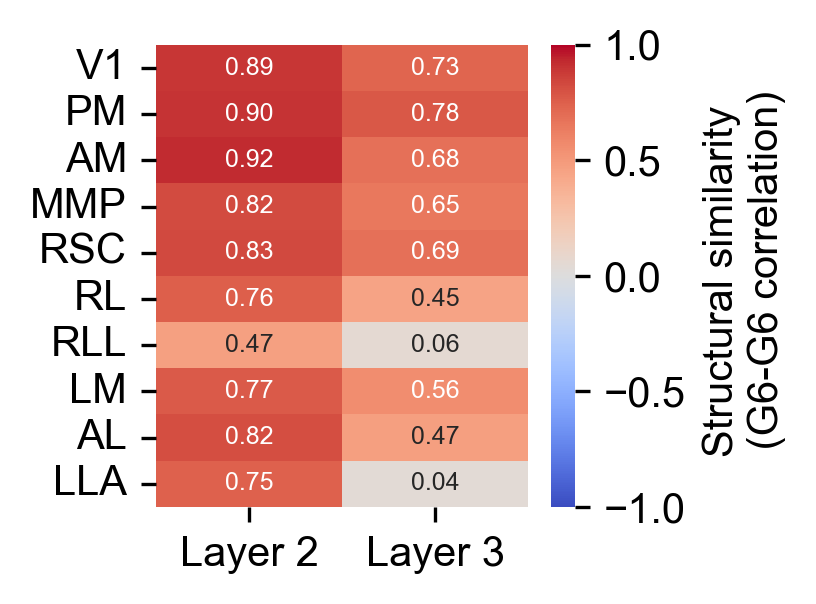

In [272]:
plt.figure(figsize=(2,2), dpi=300)
sns.heatmap(correlations_g8, cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 6},
            cbar_kws={'label': 'Structural similarity \n (G6-G6 correlation)'})

plt.yticks(np.arange(nareas)+.5, ['V1', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA'], fontsize=10, rotation=0);
plt.xticks(np.arange(nlayers)+.5, ['Layer 2', 'Layer 3'], fontsize=10, rotation=0);

In [278]:
def plot_similarity_to_layers(correlations_g8, ax):
    c = ("#BA9E98", '#2D1E3E')
    tcolors = ["#66CCEE", "#AA3377", "#AA3377", "#AA3377", "#AA3377", "#CCBB44", "#CCBB44", "#EE6677", "#EE6677", "#EE6677"]
    labels_ = ['VISp', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA']
    ax.plot(np.arange(nareas), correlations_g8[:,0], color=c[0], marker='o', markersize=2, linewidth=1)
    ax.plot(np.arange(nareas), correlations_g8[:,1], color=c[1], marker='o', markersize=2, linewidth=1)
    ax.grid(axis='y', alpha=.2, linewidth=.5)
    ax.set_xticks(np.arange(nareas))
    for tlabel, tcolor in zip(ax.get_xticklabels(), tcolors):
        tlabel.set_color(tcolor)
    ax.set_xticklabels(labels_, rotation= 90)
    ax.xaxis.set_tick_params()
    ax.set_yticks(np.arange(0,1.1,.2))
    ax.set_ylabel("Structural similarity \n (Passive vs Closed-loop)", fontsize=10)
    texts = ['Layer 2', 'Layer 3']
    text_colors = [c[0], c[1]]
    for it, t in enumerate(texts):
        ax.text(0.05, 0.35-.05*it, t, color=text_colors[it], rotation=0, ha='left', va='center', transform=ax.transAxes)
    ax.set_ylim(-.1, 1)
    sns.despine()

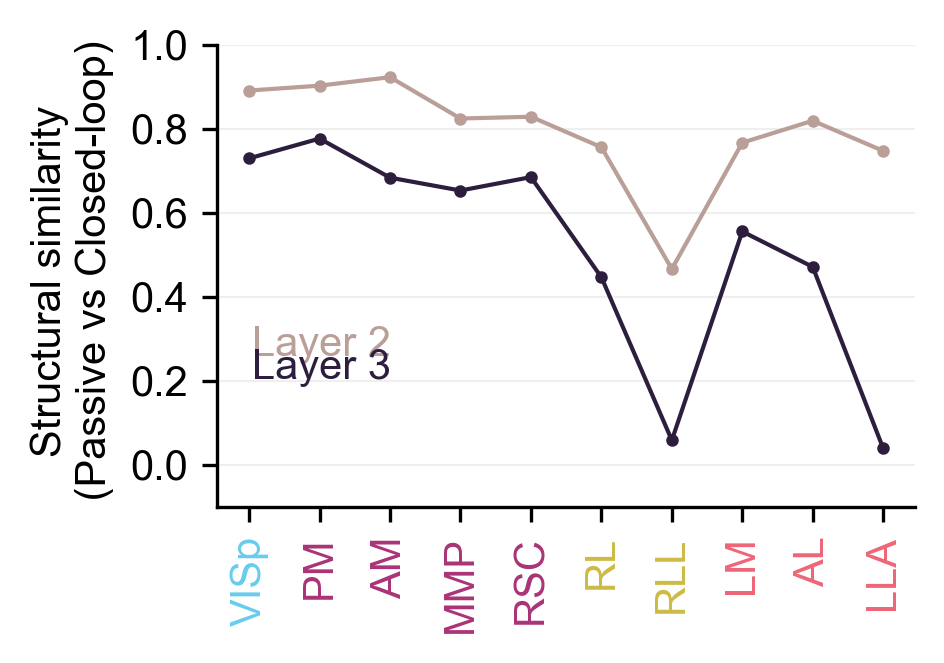

In [279]:
fig, ax = plt.subplots(figsize=(3, 2), dpi=300)
plot_similarity_to_layers(correlations_g8, ax)

In [387]:
areas_plot= ['VISp', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA']
correction_label = [(0,0), (0,0), (0,0), (0,0), (0,0), (0,0), (0,0), (0,0), (0,0), (0,0)]
def plot_consistency(avgs_per_area_closed, avgs_per_area_passive, areas, correction_label, ax):
    #ax.scatter(avgs_per_area_closed, avgs_per_area_passive, alpha=0.5, c="k")
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=.5, zorder=0)
    for i, a in enumerate(areas):
        tcolors = ["#66CCEE", "#AA3377", "#AA3377", "#AA3377", "#AA3377", "#CCBB44", "#CCBB44", "#EE6677", "#EE6677", "#EE6677"]
        ax.scatter(avgs_per_area_closed[i], avgs_per_area_passive[i], color=tcolors[i], s=15, edgecolor='k', zorder=1)
        cx = correction_label[i][0]
        cy = correction_label[i][1]
        ax.text(avgs_per_area_closed[i]+cx, avgs_per_area_passive[i]+cy, a, fontsize=7, ha='center', va='bottom', color=tcolors[i])
    ax.aspect = 'equal'

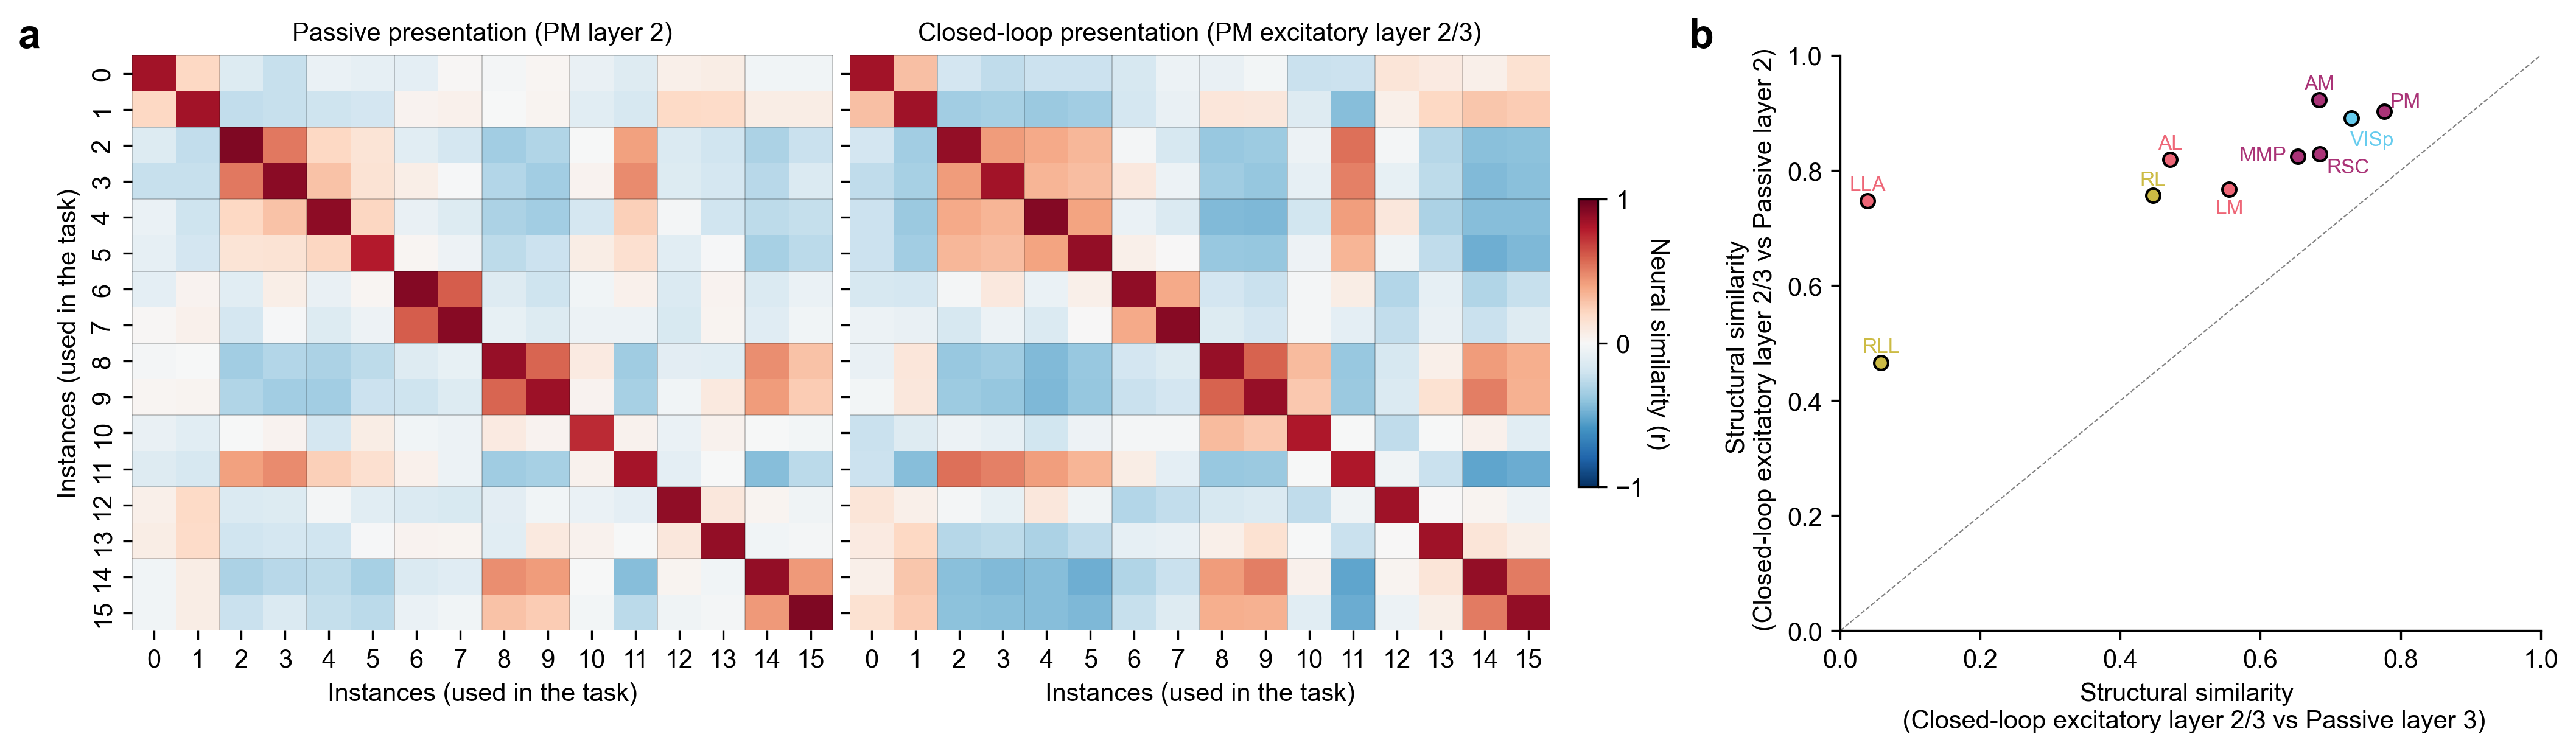

In [353]:
fig = plt.figure(figsize=(14, 4), dpi=300, layout='constrained')
axs = fig.subplots(1, 3)

passive_mtx_pm_l2 = invariance.reduce_to_behav(passive_avg_mtx[1,0])
closed_loop_pm_exc = mean_mtx[1,0]
for i, m in enumerate([passive_mtx_pm_l2, closed_loop_pm_exc], start=0):
    sns.heatmap(m, cmap='RdBu_r', vmin=-1, vmax=1, center=0, rasterized=True, ax=axs[i], cbar=False)
    axs[i].vlines(np.arange(0, m.shape[1]+1,2), ymin=0, ymax=m.shape[0], color='k', linewidth=0.1)
    axs[i].hlines(np.arange(0, m.shape[0]+1,2), xmin=0, xmax=m.shape[1], color='k', linewidth=0.1)
#make axs 0 and 1 share the same y-axis
axs[0].sharey(axs[1])
axs[1].tick_params(labelleft=False)
axs[0].set_ylabel("Instances (used in the task)")
axs[0].set_xlabel("Instances (used in the task)")
axs[1].set_xlabel("Instances (used in the task)")
axs[0].set_title("Passive presentation (PM layer 2)", fontsize=10, loc='center')
axs[1].set_title("Closed-loop presentation (PM excitatory layer 2/3)", fontsize=10, loc='center')
im = axs[0].collections[0]  
cbar = fig.colorbar(
    im,
    ax=[axs[0], axs[1]],  
    shrink=0.5,
    aspect=15,
    pad= 0.02,
    location='right', 
)
cbar.set_label("Neural similarity (r)", rotation=270, labelpad=10)
cbar.set_ticks([-1, 0, 1])
cbar.ax.tick_params(labelsize=10)

#plot_consistency(avgs_per_area_closed, avgs_per_area_passive, areas_plot, axs[3])
axs[2].set_ylim(0, 1)
axs[2].set_xlim(0, 1)
axs[2].set_xlabel("Structural similarity \n (Closed-loop excitatory layer 2/3 vs Passive layer 3)")
axs[2].set_ylabel("Structural similarity \n (Closed-loop excitatory layer 2/3 vs Passive layer 2)")
add_panel_label(axs[0], "a", xoffset=-0.13, yoffset=1, fontsize=16, fontweight="bold", ha="right", va="bottom")
add_panel_label(axs[2], "b", xoffset=-0.18, yoffset=1, fontsize=16, fontweight="bold", ha="right", va="bottom")
areas_plot= ['VISp', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA']
correction_label = [(.03,-.055), (.03,0), (0,0.01), (-.05,-.015), (.04,-.04), (0,.01), (0,.01), (0,-.05), (0,.01), (0,.01)]
plot_consistency(correlations_g8[:,1], correlations_g8[:,0], areas_plot, correction_label, axs[2])


In [392]:
def plot_neuron_counts(df_counts, ax=None):
    import matplotlib.ticker as ticker
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))
    ax = sns.pointplot(data=df_counts, y='area', x='area_ct_n', hue='cell_type', palette=["#BA9E98", "#2D1E3E"],
                    dodge=0.3, markersize=1, errorbar=('se'), err_kws={'linewidth': 1.5}, legend=False, linestyle="none", ax=ax)
    ax.set_xscale('log')
    ax.grid(True, which="both", ls="--", alpha=0.2, axis='x')
    ax.tick_params(axis='x', which='major', pad=-1)
    ax.xaxis.set_minor_locator(ticker.NullLocator())
    ax.set_ylabel("")
    ax.set_xlabel("Avg. number of neurons \n per mouse (log scale)");
    ax.text(0.05, 1, "Excitatory", color="#BA9E98", rotation=0, ha='left', va='center', transform=ax.transAxes, size=8)
    ax.text(0.05, 0.97, "Inhibitory", color="#2D1E3E", rotation=0, ha='left', va='center', transform=ax.transAxes, size=8)
    tcolors = ["#66CCEE", "#AA3377", "#AA3377", "#AA3377", "#AA3377", "#CCBB44", "#CCBB44", "#EE6677", "#EE6677", "#EE6677"]
    for tlabel, tcolor in zip(ax.get_yticklabels(), tcolors):
        tlabel.set_color(tcolor)
    labels_ = ['VISp', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA']
    ax.set_yticks(ax.get_yticks());
    ax.set_yticklabels(labels_, ha='right')
    sns.despine()

df_counts = pd.read_csv(r"C:\Users\labadmin\Documents\category-neural\scripts\rsm_passive\closed_loop_neural_counts.csv")

In [399]:
pval_train

array([[0.6599, 0.4592],
       [0.4306, 0.4555],
       [0.4571, 0.7586],
       [0.4129, 0.6247],
       [0.5506, 0.6818],
       [0.5634, 0.588 ],
       [0.8945, 0.673 ],
       [0.3258, 0.2372],
       [0.2552, 0.3138],
       [0.4038, 0.1573]])

In [398]:
pvals_corrected_train

array([[0.73322222, 0.75755556],
       [0.70425   , 0.75755556],
       [0.70425   , 0.7586    ],
       [0.70425   , 0.75755556],
       [0.70425   , 0.75755556],
       [0.70425   , 0.75755556],
       [0.8945    , 0.75755556],
       [0.70425   , 0.75755556],
       [0.70425   , 0.75755556],
       [0.70425   , 0.75755556]])

In [400]:
pval_test

array([[0.056 , 0.0481],
       [0.0048, 0.0039],
       [0.005 , 0.1747],
       [0.0058, 0.2422],
       [0.0698, 0.15  ],
       [0.0291, 0.0623],
       [0.5411, 0.1948],
       [0.0079, 0.0618],
       [0.0302, 0.103 ],
       [0.2853, 0.2829]])

In [401]:
pvals_corrected_test

array([[0.08      , 0.15575   ],
       [0.01933333, 0.039     ],
       [0.01933333, 0.2435    ],
       [0.01933333, 0.26911111],
       [0.08725   , 0.2435    ],
       [0.05033333, 0.15575   ],
       [0.5411    , 0.2435    ],
       [0.01975   , 0.15575   ],
       [0.05033333, 0.206     ],
       [0.317     , 0.2829    ]])

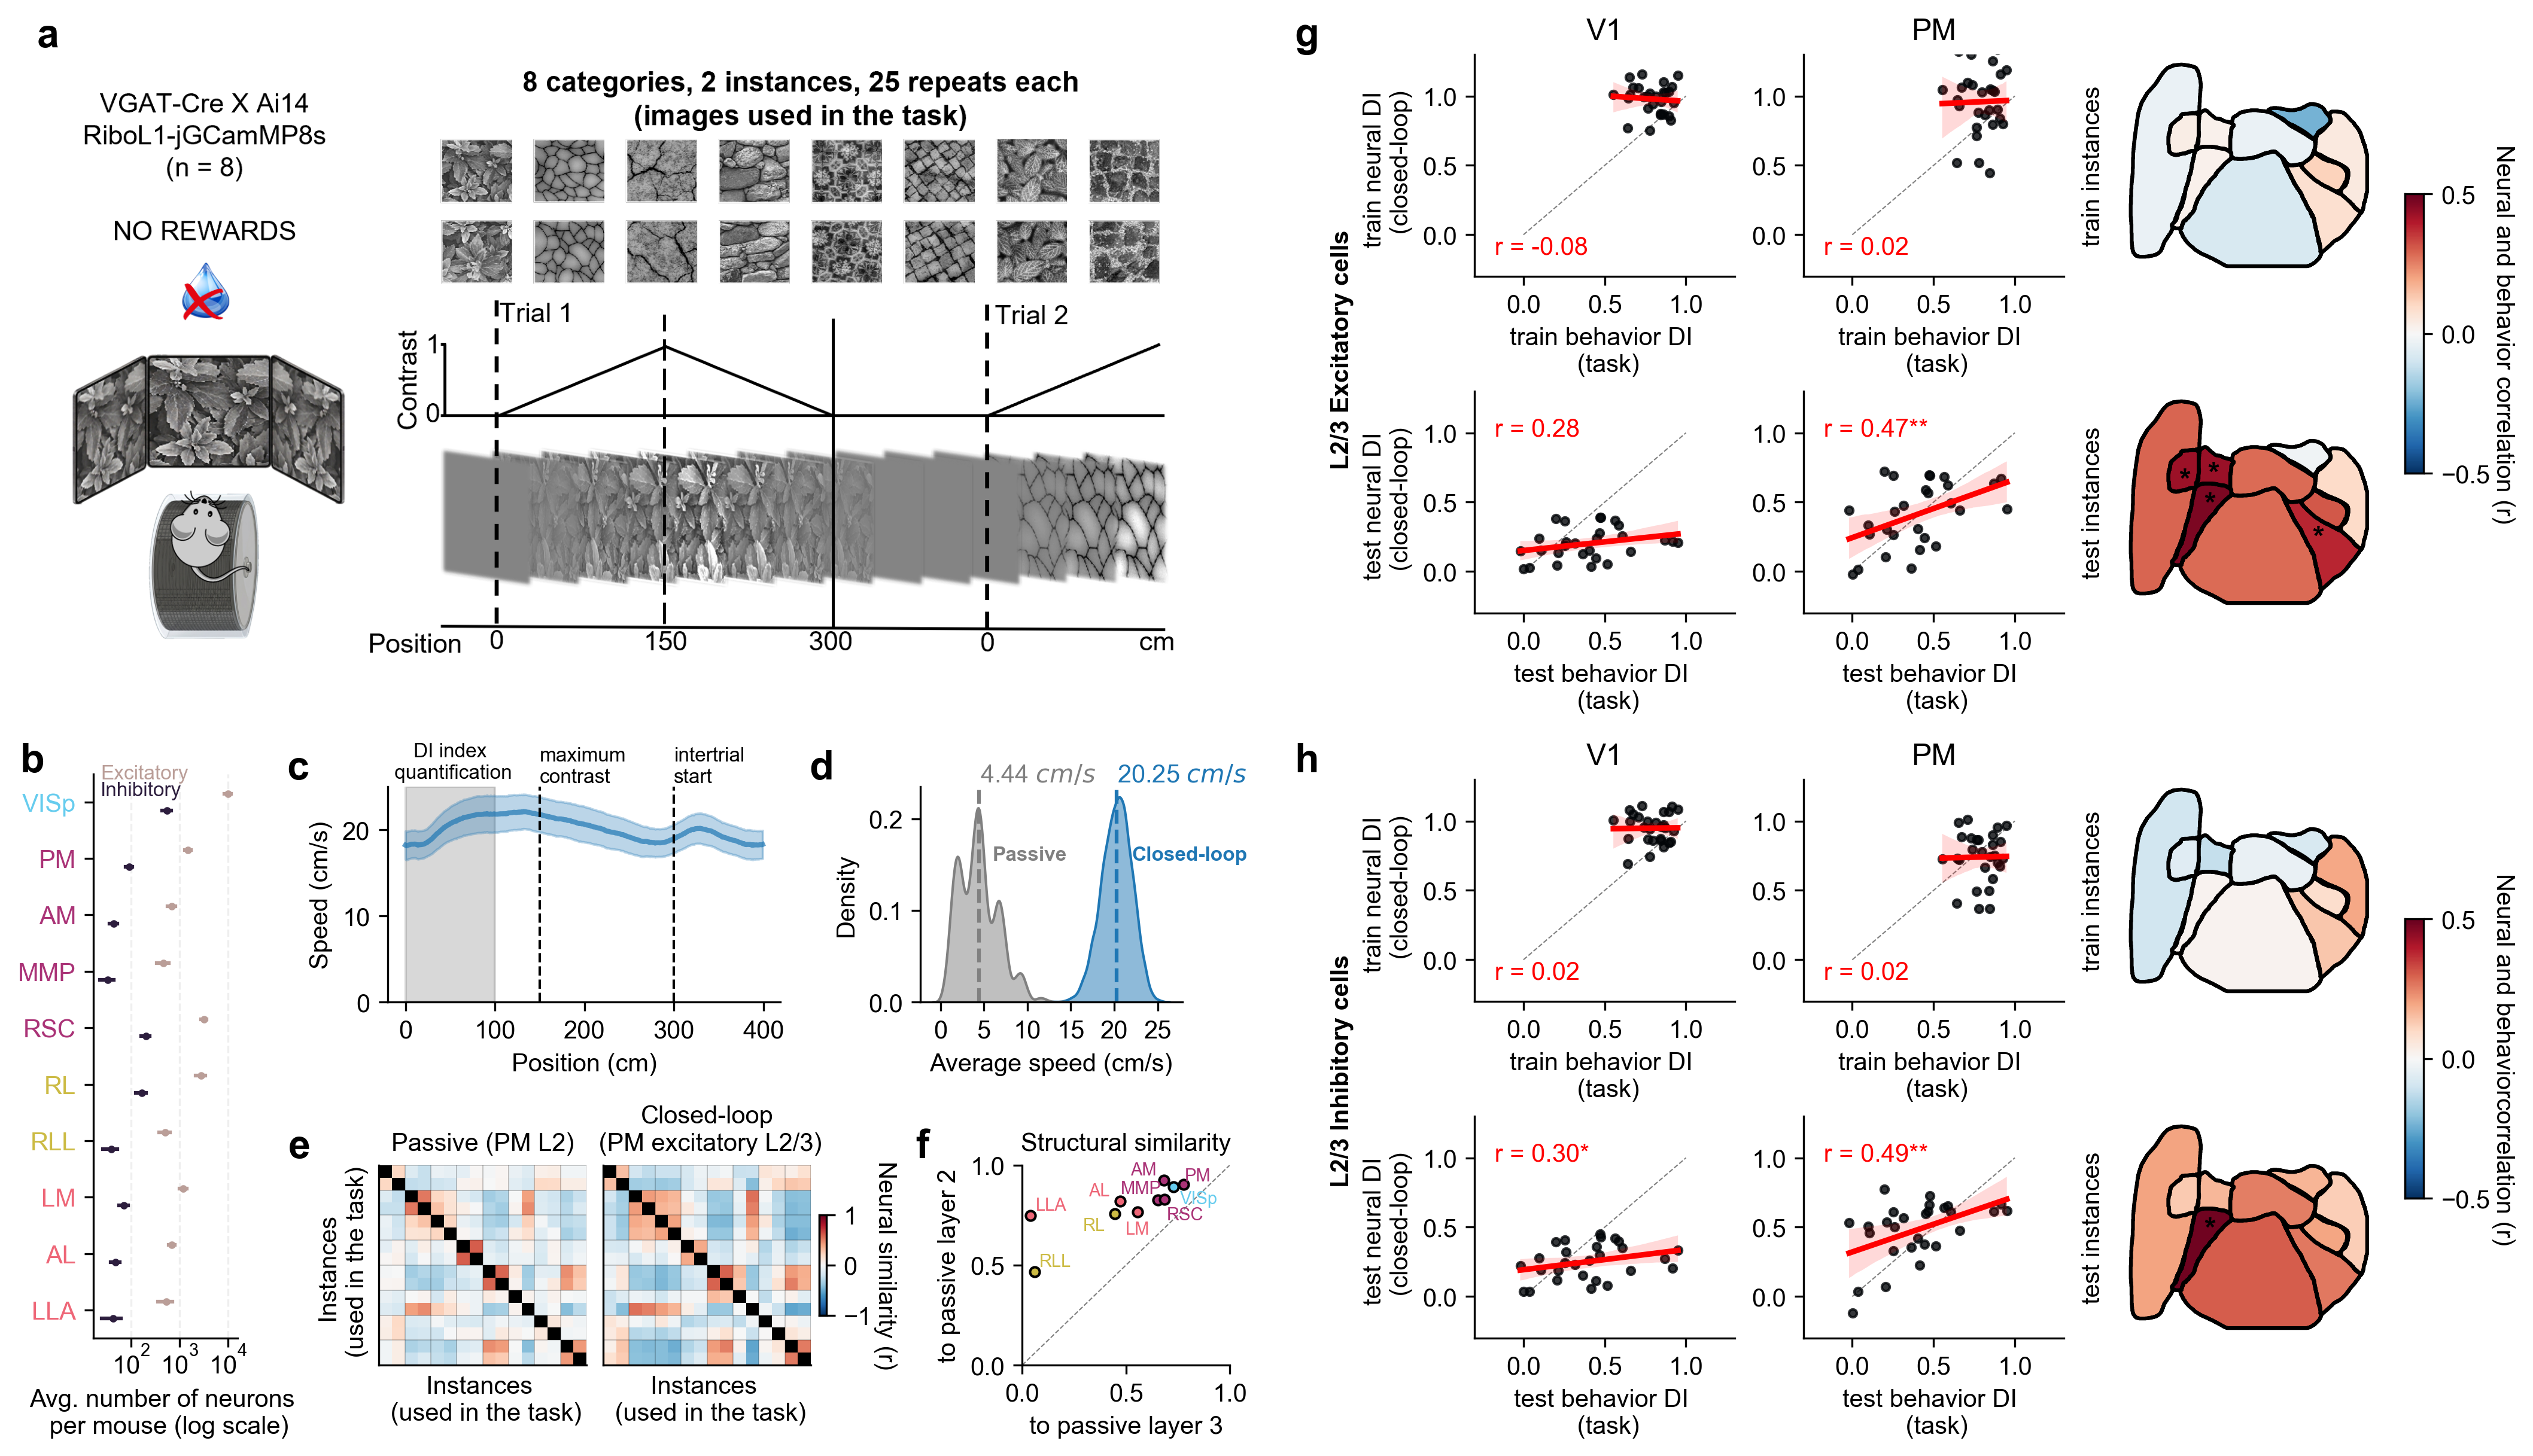

In [397]:
def show_image(ax, img_path):
    ax.imshow(plt.imread(img_path))
    ax.axis('off')
    
fig = plt.figure(figsize=(14, 8), dpi=300, layout='constrained')
subfigs = fig.subfigures(1, 2, width_ratios=[.5, .5])
img_fig = subfigs[0].subfigures(2, 1, height_ratios=[.5, .5])
img_ax = img_fig[0].subplots(1, 1)
bottom_row_fig = img_fig[1].subfigures(1, 2, width_ratios=[.2, .8])
neural_counts_ax = bottom_row_fig[0].subplots(1, 1)
subrow1_figs = bottom_row_fig[1].subfigures(2, 1, height_ratios=[.5, .5])
rsm_ax = subrow1_figs[1].subplots(1, 3, width_ratios=[.33, .33, .33])
speed_ax = subrow1_figs[0].subplots(1, 2, width_ratios=[.6, .4])


show_image(img_ax, r"C:\Users\labadmin\Pictures\closed_loop_presentation.png")
plot_neuron_counts(df_counts, ax=neural_counts_ax)


passive_mtx_pm_l2 = invariance.reduce_to_behav(passive_avg_mtx[1,0])
closed_loop_pm_exc = mean_mtx[1,0]
mask = np.eye(16, dtype=bool)
   
for i, m in enumerate([passive_mtx_pm_l2, closed_loop_pm_exc], start=0):
    rsm_ax[i].set_facecolor('black')
    sns.heatmap(m, cmap='RdBu_r', vmin=-1, vmax=1, center=0, rasterized=True, ax=rsm_ax[i], mask=mask, cbar=False)
    rsm_ax[i].vlines(np.arange(0, m.shape[1]+1,2), ymin=0, ymax=m.shape[0], color='k', linewidth=0.1)
    rsm_ax[i].hlines(np.arange(0, m.shape[0]+1,2), xmin=0, xmax=m.shape[1], color='k', linewidth=0.1)
#make axs 0 and 1 share the same y-axis
rsm_ax[0].sharey(rsm_ax[1])
rsm_ax[1].tick_params(labelleft=False)
rsm_ax[0].set_xticks([])
rsm_ax[1].set_xticks([])
rsm_ax[0].set_yticks([])
rsm_ax[0].set_ylabel("Instances \n (used in the task)")
rsm_ax[0].set_xlabel("Instances \n (used in the task)")
rsm_ax[1].set_xlabel("Instances \n (used in the task)")
rsm_ax[1].set_ylabel("")
rsm_ax[0].set_title("Passive (PM L2)", fontsize=10, loc='center')
rsm_ax[1].set_title("Closed-loop\n (PM excitatory L2/3)", fontsize=10, loc='center')
im = rsm_ax[0].collections[0]  
cbar = fig.colorbar(
    im,
    ax=[rsm_ax[0], rsm_ax[1]],  
    shrink=0.5,
    aspect=15,
    pad= 0.02,
    location='right', 
)
cbar.set_label("Neural similarity (r)", rotation=270, labelpad=10)
cbar.set_ticks([-1, 0, 1])
cbar.ax.tick_params(labelsize=10)

rsm_ax[2].set_ylim(0, 1)
rsm_ax[2].set_xlim(0, 1)
rsm_ax[2].set_xlabel("to passive layer 3")
rsm_ax[2].set_ylabel("to passive layer 2")
rsm_ax[2].set_title("Structural similarity", fontsize=10, loc='center')




plot_interp_speed(stack_speed, speed_ax[0], xlabel="Position (cm)", ylabel="Speed (cm/s)")
speed_ax[0].set_ylim(0, 25)
plot_speed_interp_avg(avg_speeds_f100, ax=speed_ax[1], color='tab:blue')
plot_speed_interp_avg(g8_speed_avg, ax=speed_ax[1], color='grey')


subrows = subfigs[1].subfigures(2, 1, height_ratios=[.5, .5])
exc_rel_axs = subrows[0].subplots(2, 3, width_ratios=[.33, .33, .33])
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISp", "exc", sig_coor=(.05,.1), norm=True, ax=exc_rel_axs[0,0])
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISpm", "exc", sig_coor=(.05,.1), norm=True, ax=exc_rel_axs[0,1])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISp", "exc", sig_coor=(.05,.8), norm=True, ax=exc_rel_axs[1,0])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISpm", "exc", sig_coor=(.05,.8), norm=True, ax=exc_rel_axs[1,1])
for ax in exc_rel_axs.flatten()[[0,1,3,4]]:
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlim(-0.3, 1.3)
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=.5, zorder=0)
exc_rel_axs[0,0].set_xlabel("train behavior DI \n (task)")
exc_rel_axs[0,1].set_xlabel("train behavior DI \n (task)")
exc_rel_axs[1,0].set_xlabel("test behavior DI \n (task)")
exc_rel_axs[1,1].set_xlabel("test behavior DI \n (task)")
exc_rel_axs[0,0].set_ylabel("train neural DI \n (closed-loop)")
exc_rel_axs[1,0].set_ylabel("test neural DI \n (closed-loop)")
exc_rel_axs[0,0].set_title("V1", loc="center")
exc_rel_axs[0,1].set_title("PM", loc="center")
cmap = plt.get_cmap('RdBu_r')
vmin = np.round(corr_train.min(), 1)
vmax = np.round(corr_test.max(), 1)
plot_brain_regions(countours, corr_train[:,0], ax=exc_rel_axs[0,2], p_values=pvals_corrected_train[:,0], cmap=cmap, vlim=(-vmax, vmax), show_labels=True)
plot_brain_regions(countours, corr_test[:,0], ax=exc_rel_axs[1,2], p_values=pvals_corrected_test[:,0], cmap=cmap, vlim=(-vmax, vmax), show_labels=True)
exc_rel_axs[0,2].text(-0.1, 0.5,"train instances", fontsize=10, rotation=90, ha='center', va='center', transform=exc_rel_axs[0,2].transAxes)
exc_rel_axs[1,2].text(-0.1, 0.5,"test instances", fontsize=10, rotation=90, ha='center', va='center', transform=exc_rel_axs[1,2].transAxes)
im = exc_rel_axs[0,2].collections[0]  
cbar = subrows[0].colorbar(
    im,
    ax=[exc_rel_axs[0,2], exc_rel_axs[1,2]],  
    shrink=0.5,
    aspect=15,
    pad= 0.1,
    location='right', 
)
cbar.set_label("Neural and behavior correlation (r)", rotation=270, labelpad=10)
cbar.set_ticks([-0.5, 0, 0.5])
cbar.ax.tick_params(labelsize=10)
inh_rel_axs = subrows[1].subplots(2, 3, width_ratios=[.33,.33,.33])
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISp", "inh", sig_coor=(.05,.1), norm=True, ax=inh_rel_axs[0,0])
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISpm", "inh", sig_coor=(.05,.1), norm=True, ax=inh_rel_axs[0,1])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISp", "inh", sig_coor=(.05,.8), norm=True, ax=inh_rel_axs[1,0])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISpm", "inh", sig_coor=(.05,.8), norm=True, ax=inh_rel_axs[1,1])
for ax in inh_rel_axs.flatten()[[0,1,3,4]]:
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlim(-0.3, 1.3)
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=.5, zorder=0)
inh_rel_axs[0,0].set_xlabel("train behavior DI \n (task)")
inh_rel_axs[0,1].set_xlabel("train behavior DI \n (task)")
inh_rel_axs[1,0].set_xlabel("test behavior DI \n (task)")
inh_rel_axs[1,1].set_xlabel("test behavior DI \n (task)")
inh_rel_axs[0,0].set_ylabel("train neural DI \n (closed-loop)")
inh_rel_axs[1,0].set_ylabel("test neural DI \n (closed-loop)")
inh_rel_axs[0,0].set_title("V1", loc="center")
inh_rel_axs[0,1].set_title("PM", loc="center")
plot_brain_regions(countours, corr_train[:,1], ax=inh_rel_axs[0,2], p_values=pvals_corrected_train[:,1], cmap=cmap, vlim=(-vmax, vmax), show_labels=True)
plot_brain_regions(countours, corr_test[:,1], ax=inh_rel_axs[1,2], p_values=pvals_corrected_test[:,1], cmap=cmap, vlim=(-vmax, vmax), show_labels=True)
inh_rel_axs[0,2].text(-0.1, 0.5,"train instances", fontsize=10, rotation=90, ha='center', va='center', transform=inh_rel_axs[0,2].transAxes)
inh_rel_axs[1,2].text(-0.1, 0.5,"test instances", fontsize=10, rotation=90, ha='center', va='center', transform=inh_rel_axs[1,2].transAxes)
im = inh_rel_axs[0,2].collections[0]  
cbar = subrows[1].colorbar(
    im,
    ax=[inh_rel_axs[0,2], inh_rel_axs[1,2]],  
    shrink=0.5,
    aspect=15,
    pad= 0.1,
    location='right', 
)
cbar.set_label("Neural and behaviorcorrelation (r)", rotation=270, labelpad=10)
cbar.set_ticks([-0.5, 0, 0.5])
cbar.ax.tick_params(labelsize=10)
sns.despine()
add_panel_label(img_ax, "a", xoffset=0, yoffset=1, fontsize=16, fontweight="bold", ha="right", va="bottom")
add_panel_label(neural_counts_ax, "b", xoffset=-0.34, yoffset=.99, fontsize=16, fontweight="bold", ha="right", va="bottom")
add_panel_label(rsm_ax[0], "e", xoffset=-0.33, yoffset=1, fontsize=16, fontweight="bold", ha="right", va="bottom")
add_panel_label(rsm_ax[2], "f", xoffset=-0.45, yoffset=1, fontsize=16, fontweight="bold", ha="right", va="bottom")
add_panel_label(speed_ax[0], "c", xoffset=-0.2, yoffset=1, fontsize=16, fontweight="bold", ha="right", va="bottom")
add_panel_label(speed_ax[1], "d", xoffset=-0.33, yoffset=1, fontsize=16, fontweight="bold", ha="right", va="bottom")
add_panel_label(exc_rel_axs[0,0], "g", xoffset=-0.6, yoffset=1, fontsize=16, fontweight="bold", ha="right", va="bottom")
add_panel_label(inh_rel_axs[0,0], "h", xoffset=-0.6, yoffset=1, fontsize=16, fontweight="bold", ha="right", va="bottom")
speed_ax[1].text(6, .15, "Passive", size=8, ha='left', va='bottom', color='grey', fontweight='bold')
rsm_ax[2].set_yticks([0.0, 0.5, 1.0])
speed_ax[1].text(22, .15, "Closed-loop", size=8, ha='left', va='bottom', color='tab:blue', fontweight='bold')
speed_ax[1].set_xticks([0, 5, 10, 15, 20, 25])
speed_ax[1].set_xlabel("Average speed (cm/s)")
fig.text(0.53, 0.68, "L2/3 Excitatory cells", ha='center', va='bottom', fontsize=10, fontweight='bold', rotation=90)
fig.text(0.53, 0.18, "L2/3 Inhibitory cells", ha='center', va='bottom', fontsize=10, fontweight='bold', rotation=90)
areas_plot= ['VISp', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA']
correction_label = [(.12,-.1), (.07,0), (-0.1,0.01), (-.08,.015), (.1,-.12), (-.1,-.1), (0.1,.01), (0,-.13), (-.1,.01), (0.1,.01)]
plot_consistency(correlations_g8[:,1], correlations_g8[:,0], areas_plot, correction_label, rsm_ax[2])
fig.savefig(r"C:\Users\labadmin\Documents\OneshotPaper\supp6.pdf", dpi=300, bbox_inches='tight')

# compute it for top10%

In [192]:
def signal_variance(stim_resp):
    NN = stim_resp.shape[0]
    nstim = stim_resp.shape[1]
    nreps = stim_resp.shape[2]
    s2 = np.zeros((2, nstim, NN), 'float32')
    for j in range(nstim):
        s2[0, j] = stim_resp[:, j, ::2].mean(1)
        s2[1, j] = stim_resp[:, j, 1::2].mean(1)
    ss = s2 - np.mean(s2,1)[:,np.newaxis,:]
    ss = ss / np.mean(ss**2,1)[:,np.newaxis,:]**.5
    csig = (ss[0] * ss[1]).mean(0)
    return csig

In [ ]:
small_areas = np.array([8,0,1,2,9,3,4,5,6,7])
areas_names = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
overall_mtx = np.full((db_.shape[0], len(small_areas), 2, 16, 16), np.nan)
for i, row in db_.iterrows():
    name, datexp, blk = row['mname'], row["datexp"], row["blk"]    
    m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, return_iscell=True,
                        data_path=ROOT_PATH, ret_path=RET_PATH,  mdl_path=MDL_PATH, opt_tlag = 1)
    save_path = Path(MDL_PATH).joinpath(f"{m.name}/{m.datexp}/{m.blk}")
    stim_resp = get_stim_response_mtx(m, segment=(0, 100), z=True)
    cc = signal_variance(stim_resp)
    for iarea, a in enumerate(small_areas):
        for ic, ctype in enumerate(["exc", "inh"]):
            ia, ip, it = filter_neurons(m, area=a, plane=0, ctype=ctype)
            print(f"Mouse: {m.name}, Area: {areas_names[iarea]}, Cell type: {ctype}")
            selection = ia & ip & it
            print(f"area & type selection: {np.sum(selection)}")
            n_area_type = np.sum(selection)
            if n_area_type == 0:
                continue
            # Determine the target count: at least 100, or all available if under 100,
            # or the top 10% if that yields more than 100.
            target_n = min(n_area_type, max(100, int(np.ceil(0.1 * n_area_type))))
            if target_n == n_area_type:
                sel = selection
            else:
                # Find the threshold value for the top `target_n` elements
                sub_cc = cc[selection]
                tsh = np.nanpercentile(sub_cc, 100 * (1 - target_n / n_area_type))
                sel = selection & (cc >= tsh)
            print(f"mouse: {m.name}, Area: {areas_names[iarea]}, Cell type: {ctype}, area_type: {n_area_type}, selected neurons: {np.sum(sel)}")
            sel_neurons = stim_resp[sel,:,:]
            rsm_ = get_rsm(m, sel_neurons)
            overall_mtx[i, iarea, ic,:,:] = rsm_
    np.save(save_path.joinpath("overall_mtx_closed_loop_z_pctile.npy"), overall_mtx[i,:,:,:,:])

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG56\2026_07_15\3
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'interp_spks'])


C:\Users\labadmin\AppData\Local\Temp\ipykernel_34364\3014813336.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  avg_resp = zscore(avg_resp, axis=1)
C:\Users\labadmin\AppData\Local\Temp\ipykernel_34364\3613010661.py:10: RuntimeWarning: invalid value encountered in divide
  ss = ss / np.mean(ss**2,1)[:,np.newaxis,:]**.5


Mouse: VG56, Area: VISp, Cell type: exc
area & type selection: 13555
mouse: VG56, Area: VISp, Cell type: exc, area_type: 13555, selected neurons: 1356
Mouse: VG56, Area: VISp, Cell type: inh
area & type selection: 651
mouse: VG56, Area: VISp, Cell type: inh, area_type: 651, selected neurons: 100
Mouse: VG56, Area: VISpm, Cell type: exc
area & type selection: 1499
mouse: VG56, Area: VISpm, Cell type: exc, area_type: 1499, selected neurons: 150
Mouse: VG56, Area: VISpm, Cell type: inh
area & type selection: 86
mouse: VG56, Area: VISpm, Cell type: inh, area_type: 86, selected neurons: 86
Mouse: VG56, Area: VISam, Cell type: exc
area & type selection: 803
mouse: VG56, Area: VISam, Cell type: exc, area_type: 803, selected neurons: 100
Mouse: VG56, Area: VISam, Cell type: inh
area & type selection: 62
mouse: VG56, Area: VISam, Cell type: inh, area_type: 62, selected neurons: 62
Mouse: VG56, Area: VISmmp, Cell type: exc
area & type selection: 763
mouse: VG56, Area: VISmmp, Cell type: exc, are

C:\Users\labadmin\AppData\Local\Temp\ipykernel_34364\3613010661.py:10: RuntimeWarning: invalid value encountered in divide
  ss = ss / np.mean(ss**2,1)[:,np.newaxis,:]**.5
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


Mouse: VG59, Area: VISp, Cell type: exc
area & type selection: 6931
mouse: VG59, Area: VISp, Cell type: exc, area_type: 6931, selected neurons: 694
Mouse: VG59, Area: VISp, Cell type: inh
area & type selection: 247
mouse: VG59, Area: VISp, Cell type: inh, area_type: 247, selected neurons: 100
Mouse: VG59, Area: VISpm, Cell type: exc
area & type selection: 1061
mouse: VG59, Area: VISpm, Cell type: exc, area_type: 1061, selected neurons: 107
Mouse: VG59, Area: VISpm, Cell type: inh
area & type selection: 65
mouse: VG59, Area: VISpm, Cell type: inh, area_type: 65, selected neurons: 65
Mouse: VG59, Area: VISam, Cell type: exc
area & type selection: 243
mouse: VG59, Area: VISam, Cell type: exc, area_type: 243, selected neurons: 100
Mouse: VG59, Area: VISam, Cell type: inh
area & type selection: 11
mouse: VG59, Area: VISam, Cell type: inh, area_type: 11, selected neurons: 11
Mouse: VG59, Area: VISmmp, Cell type: exc
area & type selection: 99
mouse: VG59, Area: VISmmp, Cell type: exc, area_ty

...

Mouse: VG66, Area: VISp, Cell type: exc
area & type selection: 5887
mouse: VG66, Area: VISp, Cell type: exc, area_type: 5887, selected neurons: 589
Mouse: VG66, Area: VISp, Cell type: inh
area & type selection: 323
mouse: VG66, Area: VISp, Cell type: inh, area_type: 323, selected neurons: 100
Mouse: VG66, Area: VISpm, Cell type: exc
area & type selection: 1328
mouse: VG66, Area: VISpm, Cell type: exc, area_type: 1328, selected neurons: 133
Mouse: VG66, Area: VISpm, Cell type: inh
area & type selection: 63
mouse: VG66, Area: VISpm, Cell type: inh, area_type: 63, selected neurons: 63
Mouse: VG66, Area: VISam, Cell type: exc
area & type selection: 647
mouse: VG66, Area: VISam, Cell type: exc, area_type: 647, selected neurons: 100
Mouse: VG66, Area: VISam, Cell type: inh
area & type selection: 35
mouse: VG66, Area: VISam, Cell type: inh, area_type: 35, selected neurons: 35
Mouse: VG66, Area: VISmmp, Cell type: exc
area & type selection: 515
mouse: VG66, Area: VISmmp, Cell type: exc, area_t

C:\Users\labadmin\AppData\Local\Temp\ipykernel_34364\3014813336.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  avg_resp = zscore(avg_resp, axis=1)
C:\Users\labadmin\AppData\Local\Temp\ipykernel_34364\3613010661.py:10: RuntimeWarning: invalid value encountered in divide
  ss = ss / np.mean(ss**2,1)[:,np.newaxis,:]**.5


Mouse: VG64, Area: VISp, Cell type: exc
area & type selection: 17731
mouse: VG64, Area: VISp, Cell type: exc, area_type: 17731, selected neurons: 1774
Mouse: VG64, Area: VISp, Cell type: inh
area & type selection: 1173
mouse: VG64, Area: VISp, Cell type: inh, area_type: 1173, selected neurons: 118
Mouse: VG64, Area: VISpm, Cell type: exc
area & type selection: 1607
mouse: VG64, Area: VISpm, Cell type: exc, area_type: 1607, selected neurons: 161
Mouse: VG64, Area: VISpm, Cell type: inh
area & type selection: 89
mouse: VG64, Area: VISpm, Cell type: inh, area_type: 89, selected neurons: 89
Mouse: VG64, Area: VISam, Cell type: exc
area & type selection: 868
mouse: VG64, Area: VISam, Cell type: exc, area_type: 868, selected neurons: 100
Mouse: VG64, Area: VISam, Cell type: inh
area & type selection: 51
mouse: VG64, Area: VISam, Cell type: inh, area_type: 51, selected neurons: 51
Mouse: VG64, Area: VISmmp, Cell type: exc
area & type selection: 1016
mouse: VG64, Area: VISmmp, Cell type: exc, 

C:\Users\labadmin\AppData\Local\Temp\ipykernel_34364\3613010661.py:10: RuntimeWarning: invalid value encountered in divide
  ss = ss / np.mean(ss**2,1)[:,np.newaxis,:]**.5


Mouse: VG63, Area: VISp, Cell type: exc
area & type selection: 5188
mouse: VG63, Area: VISp, Cell type: exc, area_type: 5188, selected neurons: 519
Mouse: VG63, Area: VISp, Cell type: inh
area & type selection: 222
mouse: VG63, Area: VISp, Cell type: inh, area_type: 222, selected neurons: 100
Mouse: VG63, Area: VISpm, Cell type: exc
area & type selection: 2054
mouse: VG63, Area: VISpm, Cell type: exc, area_type: 2054, selected neurons: 206
Mouse: VG63, Area: VISpm, Cell type: inh
area & type selection: 137
mouse: VG63, Area: VISpm, Cell type: inh, area_type: 137, selected neurons: 100
Mouse: VG63, Area: VISam, Cell type: exc
area & type selection: 874
mouse: VG63, Area: VISam, Cell type: exc, area_type: 874, selected neurons: 100
Mouse: VG63, Area: VISam, Cell type: inh
area & type selection: 75
mouse: VG63, Area: VISam, Cell type: inh, area_type: 75, selected neurons: 75
Mouse: VG63, Area: VISmmp, Cell type: exc
area & type selection: 688
mouse: VG63, Area: VISmmp, Cell type: exc, are

In [254]:
overall_mtx = np.full((db_.shape[0], len(small_areas), 2, 16, 16), np.nan)
for i, row in db_.iterrows():
    name, datexp, blk = row['mname'], row["datexp"], row["blk"]    
    save_path = Path(MDL_PATH).joinpath(f"{name}/{datexp}/{blk}")
    overall_mtx[i,:,:,:,:] = np.load(save_path.joinpath("overall_mtx_closed_loop_z_pctile.npy"))
mean_mtx = np.nanmean(overall_mtx, axis=0)